# 🌐 Shortest-Path Percolation (SPP)

This notebook implements the **Shortest-Path Percolation (SPP)** model on a graph.


## How to use this notebook

1. Run the cells in order, top to bottom.
2. Edit **only** the "Central Configuration" cell to change the network, the selection strategy, the random seed, or the simulation parameters.
3. The "Usage / Demonstration" cell at the end reads the central configuration and launches the simulation -- no other cell needs to be touched when changing `selection_strategy`.

> **Model dynamics.** Changing `selection_strategy` only changes how the **source** and **target** pair.

## Contents

1. Library imports
2. Central configuration (selection strategy, seed, network/simulation parameters)
3. Network generation
4. Conversion to CSR (NumPy)
5. Random number generator (RNG)
6. CSR utilities and centrality measures (hub, closeness, betweenness, DomiRank)
7. BFS and shortest-path sampling
8. Geometric distribution helper
9. Vertex selection strategies (`select_node`, `selection_strategy`, validation)
10. Unified pairwise attack core (Phase 1)
11. Lazy pair sampling (Phase 2, Fenwick tree)
12. Cluster reconstruction (modified Newman-Ziff)
13. Orchestrator (`efficient_pair_removal`)
14. Parallel runner (`main`)
15. Quick tests of the selection strategies
16. Summary table of available strategies
17. Usage / Demonstration
18. Final notes and scaling limitations


## 📚 Library Imports


In [1]:
# Core
import os
import time
import math
import random
import tempfile
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Graphs
import networkx as nx

# Sparse linear algebra (used by the "domirank" selection strategy)
import scipy as sp
import scipy.sparse
import scipy.sparse.linalg

# Parallelism
import multiprocessing as mp
from joblib import Parallel, delayed

# Numba (optional). Without it, @njit becomes a no-op and the notebook runs in
# pure Python (same logic, much slower). Install with `pip install numba` for a
# large performance gain (50-100x) on the @njit hot loops.
try:
    from numba import njit
    HAS_NUMBA = True
except Exception:
    HAS_NUMBA = False
    def njit(*args, **kwargs):
        if len(args) == 1 and callable(args[0]):
            return args[0]
        def _decorator(f):
            return f
        return _decorator

print(f"Numba available: {HAS_NUMBA}")


Numba available: True


## 🎛️ Central Configuration of Network

This is the **cell you need to edit** to change the example network you want to use.

In [2]:
# Seed for reproducibility (Python `random` + NumPy).
RANDOM_SEED = 42

# Example network used in the walkthrough sections and the final demonstration.
NETWORK_PARAMS = dict(N=500, avg_k=3)     # Erdős–Rényi: N nodes, average degree avg_k
NETWORK_DIR = "network-save"
NETWORK_FILENAME = "er500-graph.txt"

## 🛰️ Network Generation

Functions to generate and save networks, used both by the walkthrough examples below and to build the network for the final demonstration.


In [3]:
def generate_ws_graph(N: int, k: int, p: float, seed: int | None = None) -> nx.Graph:
    """
    Generate a Small-World network using the Watts–Strogatz model.

    Parameters
    ----------
    N : int
        Number of nodes.
    k : int
        Each node is connected to k nearest neighbors in a ring topology (must be even).
    p : float
        Probability of rewiring each edge (0 = regular lattice, 1 = random network).
    seed : int | None
        Optional seed for reproducibility.

    Returns
    -------
    networkx.Graph
        The generated Watts–Strogatz small-world graph.
    """
    if k % 2 != 0:
        raise ValueError("Parameter k must be even in the Watts–Strogatz model.")
    return nx.watts_strogatz_graph(N, k, p, seed=seed)


def generate_er_graph(N: int, avg_k: float, seed: int | None = None) -> nx.Graph:
    """
    Generate an Erdős–Rényi random graph G(n, p).

    Parameters
    ----------
    N : int
        Number of nodes.
    avg_k : float
        Target average degree. Used to compute the edge probability as p = avg_k / (N - 1).
    seed : int | None
        Optional seed for reproducibility.

    Returns
    -------
    networkx.Graph
        The generated Erdős–Rényi random graph.
    """
    if N < 2:
        raise ValueError("N must be >= 2")
    p = avg_k / (N - 1)
    return nx.gnp_random_graph(N, p, seed=seed, directed=False)


def generate_generalized_star(N: int, extra_edge_prob: float = 0.02, seed: int | None = None) -> nx.Graph:
    """
    Generate a Generalized Star Network:
    - One central node connected to all others (classic star structure).
    - Additional edges are randomly added between leaf nodes.

    Parameters
    ----------
    N : int
        Total number of nodes (>= 2).
    extra_edge_prob : float
        Probability of adding an edge between two leaves (0 <= p <= 1).
    seed : int | None
        Random seed for reproducibility (default=None).

    Returns
    -------
    networkx.Graph
        Graph with a generalized star structure.
    """
    if N < 2:
        raise ValueError("N must be >= 2")
    if seed is not None:
        random.seed(seed)
    G = nx.star_graph(N - 1)
    leaves = list(range(1, N))
    for i in range(len(leaves)):
        for j in range(i + 1, len(leaves)):
            if random.random() < extra_edge_prob:
                G.add_edge(leaves[i], leaves[j])
    return G


def save_graph_as_txt(G: nx.Graph, out_dir: str = "network-save", filename: str = "graph.txt",
                       one_indexed: bool = True, preserve_isolated: bool = True) -> str:
    """
    Save the graph in edge list format (u v).
    If preserve_isolated=True, writes a self-loop (i i) for each isolated node,
    ensuring that all nodes are included in the file.
    """
    os.makedirs(out_dir, exist_ok=True)
    path = Path(out_dir) / filename
    with open(path, "w", encoding="utf-8") as f:
        for u, v in G.edges():
            u = u + 1 if one_indexed else u
            v = v + 1 if one_indexed else v
            f.write(f"{u} {v}\n")
        if preserve_isolated:
            for n in G.nodes():
                if G.degree(n) == 0:
                    i = n + 1 if one_indexed else n
                    f.write(f"{i} {i}\n")
    return str(path)


### Example: generating and saving the demonstration network

Uses the parameters defined in `NETWORK_PARAMS` (central configuration cell) to generate an example Erdős–Rényi network. Change `NETWORK_PARAMS`/`NETWORK_DIR`/`NETWORK_FILENAME` in the central configuration to use Watts–Strogatz, hub-and-spoke, or your own network already saved as `.txt`.


Network saved to: network-save\er500-graph.txt (N=500, E=721)


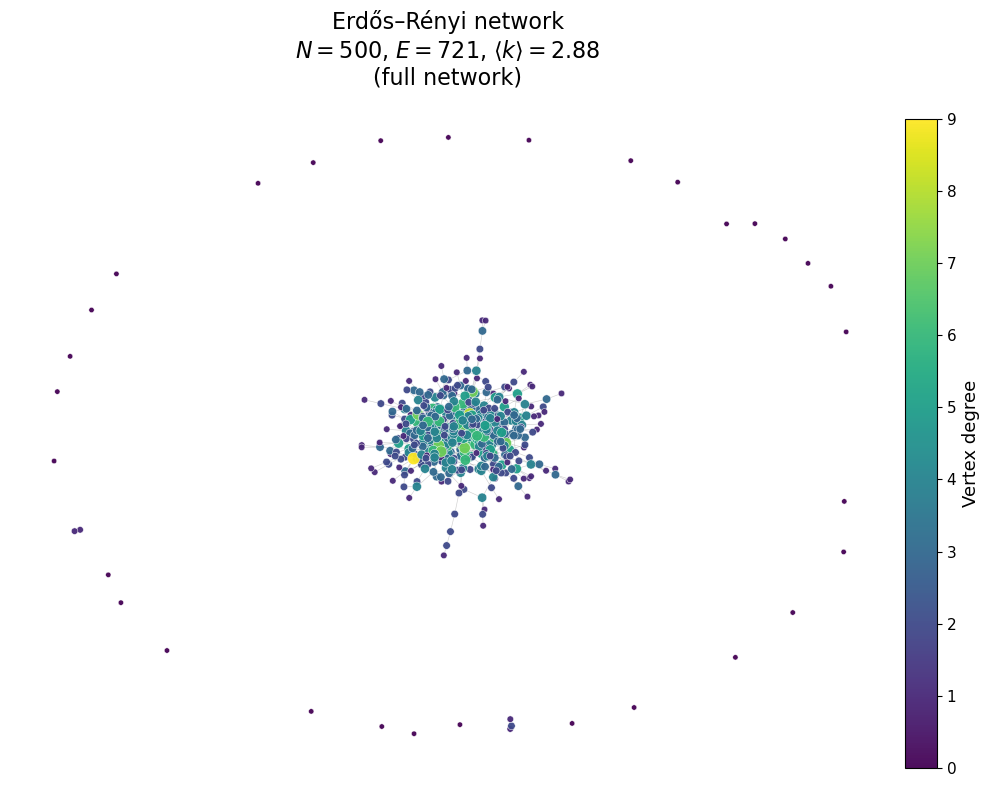

In [4]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Generate the full network
G_demo = generate_er_graph(
    NETWORK_PARAMS["N"],
    NETWORK_PARAMS["avg_k"],
    seed=RANDOM_SEED,
)

# Save the full network
network_path = save_graph_as_txt(
    G_demo,
    out_dir=NETWORK_DIR,
    filename=NETWORK_FILENAME,
)

print(
    f"Network saved to: {network_path} "
    f"(N={G_demo.number_of_nodes()}, "
    f"E={G_demo.number_of_edges()})"
)

# ============================================================
# Visualization
# ============================================================

MAX_NODES_PLOT = 1500

if G_demo.number_of_nodes() > MAX_NODES_PLOT:
    # Work with the largest connected component
    largest_component = max(
        nx.connected_components(G_demo),
        key=len,
    )

    G_connected = G_demo.subgraph(
        largest_component
    ).copy()

    # Start from the highest-degree vertex
    center_node = max(
        G_connected.degree,
        key=lambda item: item[1],
    )[0]

    # Select a connected neighborhood for visualization
    selected_nodes = list(
        nx.bfs_tree(
            G_connected,
            source=center_node,
        ).nodes()
    )[:MAX_NODES_PLOT]

    G_plot = G_connected.subgraph(
        selected_nodes
    ).copy()

    plot_description = (
        f"connected sample with "
        f"{G_plot.number_of_nodes()} vertices"
    )

else:
    G_plot = G_demo.copy()
    plot_description = "full network"


# Vertex degrees
degrees = np.array(
    [G_plot.degree(node) for node in G_plot.nodes()],
    dtype=float,
)

# Vertex size proportional to degree
if degrees.max() > degrees.min():
    node_sizes = (
        15
        + 65
        * (degrees - degrees.min())
        / (degrees.max() - degrees.min())
    )
else:
    node_sizes = np.full(
        len(degrees),
        25.0,
    )


# Layout
pos = nx.spring_layout(
    G_plot,
    seed=RANDOM_SEED,
    k=1.8 / np.sqrt(G_plot.number_of_nodes()),
    iterations=150,
)


# Figure
fig, ax = plt.subplots(
    figsize=(10, 8),
    facecolor="white",
)

ax.set_facecolor("#f7f7f7")


# Edges
nx.draw_networkx_edges(
    G_plot,
    pos,
    ax=ax,
    edge_color="#151616",
    width=0.45,
    alpha=0.20,
)


# Vertices
nodes = nx.draw_networkx_nodes(
    G_plot,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=degrees,
    cmap=plt.cm.viridis,
    edgecolors="white",
    linewidths=0.35,
    alpha=0.95,
)


# Colorbar
colorbar = fig.colorbar(
    nodes,
    ax=ax,
    fraction=0.035,
    pad=0.02,
)

colorbar.set_label(
    "Vertex degree",
    fontsize=13,
)

colorbar.ax.tick_params(
    labelsize=11,
)


# Title
ax.set_title(
    (
        "Erdős–Rényi network\n"
        rf"$N={G_demo.number_of_nodes():,}$, "
        rf"$E={G_demo.number_of_edges():,}$, "
        rf"$\langle k\rangle="
        rf"{2 * G_demo.number_of_edges() / G_demo.number_of_nodes():.2f}$"
        f"\n({plot_description})"
    ),
    fontsize=16,
    pad=16,
)


# Remove axes and borders
ax.set_axis_off()

fig.tight_layout()
plt.show()

## 🔗 Reading and Conversion to CSR (NumPy)

Graphs are stored in a **CSR** (*Compressed Sparse Row*) format built on NumPy arrays, which supports O(1) edge removal and fast neighbor iteration.


In [5]:
def read_network_from_txt(path, one_indexed=False, remove_selfloops=True):
    """
    Read a graph from a .txt file in edge list format ('i j' per line).

    Parameters
    ----------
    path : str
        Path to the text file containing the network edges.
    one_indexed : bool, optional
        If True, node IDs in the file are 1-indexed and are shifted to 0-index internally.
    remove_selfloops : bool, optional
        If True, removes self-loops (edges i i) after reading.

    Returns
    -------
    networkx.Graph
    """
    G = nx.Graph()
    with open(path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            i, j = map(int, parts[:2])
            if one_indexed:
                i, j = i - 1, j - 1
            G.add_edge(i, j)
    if remove_selfloops:
        G.remove_edges_from(nx.selfloop_edges(G))
    return G


def network_to_csr(G):
    """
    Convert a NetworkX graph into 1-indexed CSR arrays: (deg, indptr, adj, twin, N).

    deg    : int32[N+1]   current degree (initially = total degree)
    indptr : int64[N+2]   offsets; indptr[N+1] = 2E
    adj    : int32[2E]    neighbors
    twin   : int32[2E]    "twin pointer" — for each slot e in adj, twin[e] is the slot
                          of the reverse edge. Lets us find the back-edge in O(1) without
                          a linear scan, which was the main bottleneck for high-degree graphs.
    """
    nodes = sorted(G.nodes())
    id_map = {old: i + 1 for i, old in enumerate(nodes)}
    N = len(nodes)

    deg = np.zeros(N + 1, dtype=np.int32)
    for u in nodes:
        deg[id_map[u]] = G.degree(u)

    indptr = np.zeros(N + 2, dtype=np.int64)
    for i in range(1, N + 1):
        indptr[i + 1] = indptr[i] + deg[i]

    total = int(indptr[N + 1])
    adj = np.zeros(total, dtype=np.int32)
    twin = np.zeros(total, dtype=np.int32)
    pos = np.zeros(N + 1, dtype=np.int64)

    for u, v in G.edges():
        iu = id_map[u]
        iv = id_map[v]
        e_uv = indptr[iu] + pos[iu]
        e_vu = indptr[iv] + pos[iv]
        adj[e_uv] = iv
        adj[e_vu] = iu
        twin[e_uv] = e_vu
        twin[e_vu] = e_uv
        pos[iu] += 1
        pos[iv] += 1

    return deg, indptr, adj, twin, N


def save_csr_to_disk(deg, indptr, adj, twin, base_path):
    """Persist the CSR arrays (incl. twin) as four .npy files for mmap sharing between workers."""
    base_path = Path(base_path)
    base_path.mkdir(parents=True, exist_ok=True)
    np.save(base_path / "deg.npy", deg)
    np.save(base_path / "indptr.npy", indptr)
    np.save(base_path / "adj.npy", adj)
    np.save(base_path / "twin.npy", twin)
    return str(base_path)


def load_csr_mmap(base_path):
    """Open the .npy CSR arrays as memory-mapped, read-only (incl. twin)."""
    base_path = Path(base_path)
    deg = np.load(base_path / "deg.npy", mmap_mode="r")
    indptr = np.load(base_path / "indptr.npy", mmap_mode="r")
    adj = np.load(base_path / "adj.npy", mmap_mode="r")
    twin = np.load(base_path / "twin.npy", mmap_mode="r")
    return deg, indptr, adj, twin


### Example: converting the demonstration network to CSR


C:\Users\victo\AppData\Local\Temp\ipykernel_21368\2875985803.py:13: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


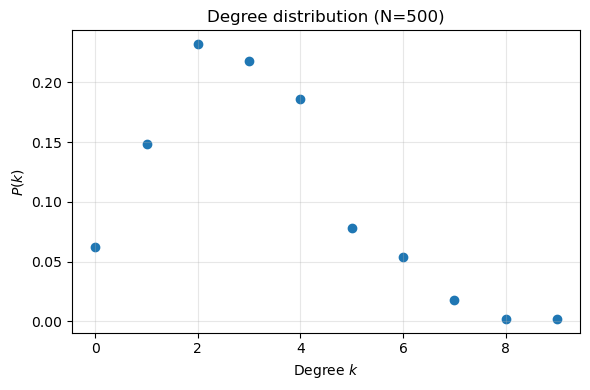

N=500, E=721, <k>=2.8840


In [6]:
G_check = read_network_from_txt(network_path, one_indexed=True, remove_selfloops=True)
deg_demo, indptr_demo, adj_demo, twin_demo, N_demo = network_to_csr(G_check)

degrees = deg_demo[1:N_demo + 1]
k_vals, counts = np.unique(degrees, return_counts=True)
p_vals = counts / counts.sum()

plt.figure(figsize=(6, 4))
plt.scatter(k_vals, p_vals)
plt.xlabel("Degree $k$")
plt.ylabel("$P(k)$")
plt.title(f"Degree distribution (N={N_demo})")
plt.grid(False, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"N={N_demo}, E={int(indptr_demo[N_demo + 1] // 2)}, <k>={degrees.mean():.4f}")


## 🔢 Random Number Generator (RNG)

The notebook exposes `genrand64_real3()` (a float in `[0,1)`) for the pure-Python slow path, and `init_rng(seed)`, which synchronizes Python's and NumPy's RNGs.

> **Note on Numba's RNG.** Numba keeps an internal RNG state for `@njit` functions that is **separate** from NumPy's own generator: calling `np.random.seed(x)` from plain Python does **not** reseed the generator used by `np.random.random()` when called from inside an `@njit` function. Since essentially the entire fast path (`random`/`hub` selection, bidirectional BFS, the lazy Phase 2 sampler) is `@njit`, `init_rng` also calls a small `@njit` helper that runs `np.random.seed(...)` **from inside** compiled code -- this is what makes `RANDOM_SEED` reproduce results end to end, not just on the slow Python path.


In [7]:
@njit(cache=True)
def _seed_njit_rng(seed):
    """Reseed Numba's internal RNG state. Must run INSIDE nopython mode: calling
    `np.random.seed()` from plain Python only reseeds NumPy's own generator, not the
    separate one used by `np.random.random()`/`np.random.randint()` inside @njit
    functions (verified empirically -- see the Markdown note above)."""
    np.random.seed(seed)


def init_rng(seed: int):
    """Seed Python's `random`, NumPy's RNG, and Numba's internal RNG (used by the
    @njit kernels) so that a given `seed` reproduces the whole pipeline end to end."""
    random.seed(seed)
    np.random.seed(seed & 0xFFFFFFFF)
    _seed_njit_rng(seed & 0xFFFFFFFF)


def genrand64_real3():
    """Random float in [0, 1) via Python's `random` (slow-path compatibility)."""
    return random.random()


# Apply the central seed defined in the configuration -- reproducibility for the demo.
init_rng(RANDOM_SEED)
print(f"RNG initialized with RANDOM_SEED={RANDOM_SEED}")


RNG initialized with RANDOM_SEED=42


## 🛠️ CSR Utilities

Low-level helpers: neighbor lookup, removal (*swap-and-pop*), the degree bucket (used to accelerate hub selection), and reconstruction into an `nx.Graph` (needed only for the centrality measures, which have no -- and need no -- `@njit` version).


In [8]:
@njit(cache=True)
def find_neighbor_pos(i, j, deg, indptr, adj):
    """Return the 1-indexed position of j in i's neighbor list, or -1.
    Kept only for the Python fallback path; the @njit hot path uses the twin pointer."""
    base = indptr[i]
    d = deg[i]
    for k in range(d):
        if adj[base + k] == j:
            return k + 1
    return -1


@njit(cache=True)
def remove_neighbor(i, k_pos, deg, indptr, adj):
    """Plain swap-and-pop (no twin/bucket bookkeeping). Kept for the Python fallback path."""
    base = indptr[i]
    last = base + deg[i] - 1
    adj[base + k_pos - 1] = adj[last]
    deg[i] -= 1


@njit(cache=True)
def _bk_init(N, deg, bk_head, bk_next, bk_prev, bk_max_arr):
    """Initialize the degree-bucket structures from `deg`."""
    for d in range(bk_head.size):
        bk_head[d] = 0
    for i in range(bk_next.size):
        bk_next[i] = 0
        bk_prev[i] = 0
    bk_max = 0
    for i in range(1, N + 1):
        d = deg[i]
        nxt = bk_head[d]
        bk_next[i] = nxt
        bk_prev[i] = 0
        if nxt != 0:
            bk_prev[nxt] = i
        bk_head[d] = i
        if d > bk_max:
            bk_max = d
    bk_max_arr[0] = bk_max


@njit(cache=True)
def _bk_decrement(i, old_d, bk_head, bk_next, bk_prev, bk_max_arr):
    """Move node i from bucket `old_d` to `old_d - 1` in O(1).
    Called AFTER deg[i] has already been decremented."""
    nxt = bk_next[i]
    prv = bk_prev[i]
    if prv == 0:
        bk_head[old_d] = nxt
    else:
        bk_next[prv] = nxt
    if nxt != 0:
        bk_prev[nxt] = prv
    new_d = old_d - 1
    nxt2 = bk_head[new_d]
    bk_next[i] = nxt2
    bk_prev[i] = 0
    if nxt2 != 0:
        bk_prev[nxt2] = i
    bk_head[new_d] = i
    if bk_head[bk_max_arr[0]] == 0:
        m = bk_max_arr[0]
        while m > 0 and bk_head[m] == 0:
            m -= 1
        bk_max_arr[0] = m


@njit(cache=True)
def remove_neighbor_twin(i, k_pos, deg, indptr, adj, twin,
                         bk_head, bk_next, bk_prev, bk_max_arr):
    """O(1) swap-and-pop that keeps the twin pointer and the degree bucket consistent."""
    base = indptr[i]
    cur = base + k_pos - 1
    last = base + deg[i] - 1
    if cur != last:
        adj[cur] = adj[last]
        twin[cur] = twin[last]
        twin[twin[cur]] = cur  # the swapped neighbor now points back at the new slot
    old_d = deg[i]
    deg[i] = old_d - 1
    _bk_decrement(i, old_d, bk_head, bk_next, bk_prev, bk_max_arr)


def csr_to_graph(deg, indptr, adj, N):
    """Rebuild an nx.Graph from the CSR arrays (only needed for centrality measures)."""
    G = nx.Graph()
    G.add_nodes_from(range(1, N + 1))
    for i in range(1, N + 1):
        base = int(indptr[i])
        for k in range(int(deg[i])):
            j = int(adj[base + k])
            if i < j:
                G.add_edge(i, j)
    return G


def get_hub_nodes(N, deg, top_k=1):
    """Top-k nodes by degree (descending)."""
    order = np.argsort(-deg[1:N + 1])
    return [int(order[i]) + 1 for i in range(min(top_k, N))]


def get_closeness_nodes(N, deg, indptr, adj, top_k=1):
    """Top-k nodes by closeness centrality (descending)."""
    G = csr_to_graph(deg, indptr, adj, N)
    clos = nx.closeness_centrality(G)
    ordered = sorted(clos.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]


def get_betweenness_nodes(N, deg, indptr, adj, top_k=1, normalized=True):
    """Top-k nodes by betweenness centrality (descending)."""
    G = csr_to_graph(deg, indptr, adj, N)
    btw = nx.betweenness_centrality(G, normalized=normalized)
    ordered = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]


### 🌀 DomiRank Centrality

Besides `random`, `hub` (degree), `closeness`, and `betweenness`, this notebook adds a `"domirank"` selection strategy, based on **DomiRank** centrality (Engsig et al., *"DomiRank Centrality: revealing structural fragility of complex networks via node dominance"*), whose reference implementation is at [github.com/mengsig/DomiRank](https://github.com/mengsig/DomiRank/tree/main/src).

> **Computational cost.** Like `closeness`/`betweenness`, `domirank` rebuilds the graph and solves a global system on every call -- it does not scale to very large `N`. Use it on small/medium networks.


In [9]:
def _to_sparse(G):
    """Coerce a NetworkX graph (or an existing scipy sparse array) into a CSR sparse array."""
    if isinstance(G, nx.Graph):
        return nx.to_scipy_sparse_array(G)
    return G.copy()


def find_eigenvalue(G):
    """
    Largest-magnitude eigenvalue of the dominant mode of the adjacency matrix, negated
    (i.e. -lambda_N). Ported directly from the DomiRank reference implementation
    (github.com/mengsig/DomiRank) — `scipy.sparse.linalg.eigs` replaces a manual bisection
    search used in the unofficial prototype notebook this was adapted from; the reference
    repository itself deprecated that bisection approach in favor of this direct eigen-solve,
    which is both simpler and numerically more robust.
    """
    eigval = sp.sparse.linalg.eigs(G.astype(np.float64), k=1, which="LR")[0][0]
    return -eigval.real


def domirank(G, analytical=True, sigma=-1, dt=0.1, epsilon=1e-5, maxIter=1000, checkStep=10):
    """
    DomiRank centrality (Engsig et al.). Returns (converged: bool, centrality: np.ndarray).

    The returned `centrality` array is indexed 0..len(G)-1, in the same order as
    `G.nodes()` when `G` is a NetworkX graph — see `generate_attack(..., node_map=...)`
    below for how to translate these positions back into real node IDs.
    """
    G = _to_sparse(G)
    try:
        if sigma == -1:
            sigma, _ = optimal_sigma(G, analytical=analytical, dt=dt, epsilon=epsilon,
                                      maxIter=maxIter, checkStep=checkStep)

        if analytical is False:
            pGAdj = (sigma * G).astype(np.float64)
            Psi = np.ones(pGAdj.shape[0], dtype=np.float64) / pGAdj.shape[0]
            maxVals = np.zeros(max(int(maxIter / checkStep), 1), dtype=np.float64)
            dt = np.float64(dt)
            j = 0
            boundary = epsilon * pGAdj.shape[0] * dt

            for i in range(maxIter):
                tempVal = (pGAdj @ (1 - Psi) - Psi) * dt
                Psi += tempVal.real
                if i % checkStep == 0:
                    if np.abs(tempVal).sum() < boundary:
                        return True, np.nan_to_num(Psi, nan=0.0)
                    maxVals[j] = float(np.nanmax(tempVal))
                    if j >= 2 and maxVals[j] > maxVals[j - 1] > maxVals[j - 2]:
                        return False, np.nan_to_num(Psi, nan=0.0)  # diverged
                    j = min(j + 1, maxVals.size - 1)
            return True, np.nan_to_num(Psi, nan=0.0)

        else:
            Psi = sp.sparse.linalg.spsolve(sigma * G + sp.sparse.identity(G.shape[0]),
                                            (sigma * G).sum(axis=-1))
            Psi = np.asarray(Psi).ravel()
            if np.any(~np.isfinite(Psi)) or np.all(Psi == 0):
                return False, np.zeros(G.shape[0])
            return True, np.nan_to_num(Psi, nan=0.0)

    except Exception as e:
        print(f"[DomiRank] Internal error while computing centrality: {e}")
        return False, np.ones(G.shape[0]) / G.shape[0]


def get_component_size(G):
    """Size of the largest weakly-connected component of a scipy sparse graph."""
    _, labels = sp.sparse.csgraph.connected_components(G, directed=True, connection="weak",
                                                         return_labels=True)
    return int(np.bincount(labels).max())


def get_link_size(G):
    """Number of (directed) nonzero entries in the sparse adjacency matrix."""
    return G.sum()


def remove_node(G, removed_nodes):
    """Zero out the rows/columns of `removed_nodes` in a sparse adjacency matrix."""
    diag = sp.sparse.csr_array(sp.sparse.eye(G.shape[0]))
    diag[removed_nodes, removed_nodes] = 0
    return diag @ G @ diag


def generate_attack(centrality, node_map=None):
    """
    Turn a centrality vector into a node ranking (highest centrality first).

    `centrality[k]` refers to the node at position `k` in the sparse matrix used to
    compute it. If the underlying graph's node IDs are NOT simply `0..len(centrality)-1`
    (e.g. the 1-indexed nodes `1..N` used throughout this notebook), you MUST pass
    `node_map = dict(enumerate(G.nodes()))` so that matrix position `k` is translated
    back to the real node ID `node_map[k]`. See the note on node indexing in the
    DomiRank section below for why this matters.
    """
    if node_map is None:
        node_map = range(len(centrality))
    else:
        node_map = list(node_map.values())
    zipped = dict(zip(node_map, centrality))
    return sorted(zipped, reverse=True, key=zipped.get)


def network_attack_sampled(G, attack_strategy, sampling=0):
    """Simulate removing nodes in `attack_strategy` order, sampling the giant component
    size every `sampling` removals. Used internally by `optimal_sigma` to score candidate
    values of sigma by how effective the resulting attack is."""
    GAdj = G.copy()
    N = GAdj.shape[0]
    if sampling == 0:
        sampling = 1 if N < 100 else int(N / 100)

    initial_component = get_component_size(GAdj)
    initial_links = get_link_size(GAdj)
    component_evolution = np.zeros(N // sampling + 1)
    links_evolution = np.zeros(N // sampling + 1)

    j = 0
    for i in range(N - 1):
        if i % sampling == 0:
            if i > 0:
                GAdj = remove_node(GAdj, attack_strategy[i - sampling:i])
            component_evolution[j] = get_component_size(GAdj) / initial_component
            links_evolution[j] = get_link_size(GAdj) / initial_links
            j += 1
    return component_evolution, links_evolution


def optimal_sigma(spArray, analytical=True, endVal=0, startval=1e-6, iterationNo=100,
                   dt=0.1, epsilon=1e-5, maxIter=100, checkStep=10, sampling=0):
    """
    Sweep sigma over (0, -0.9999/lambda_N] and return the value that produces the most
    effective dismantling attack (fewest nodes needed to fragment the network).

    Runs sequentially (no multiprocessing): spawning worker processes from inside a
    Jupyter kernel on Windows is fragile (no fork(), pickling of notebook globals), so
    this notebook keeps the reference algorithm's logic but drops the `mp.Process`
    parallelism used in the original DomiRank repo in favor of a plain loop. For the
    network sizes where the (expensive) `domirank`/`closeness`/`betweenness` selection
    modes are practical, the sequential version already runs in well under a second.
    """
    if endVal == 0:
        endVal = find_eigenvalue(spArray)

    endval = -0.9999 / endVal
    if endval <= startval:
        endval = startval * 10.0
    tempRange = np.linspace(startval, endval, num=iterationNo, endpoint=True)
    finalErrors = np.full(tempRange.shape, np.inf, dtype=float)

    for idx, sigma in enumerate(tempRange):
        try:
            ok, domiDist = domirank(spArray, analytical=analytical, sigma=sigma, dt=dt,
                                     epsilon=epsilon, maxIter=maxIter, checkStep=checkStep)
            if (not ok) or domiDist is None or not np.all(np.isfinite(domiDist)):
                continue
            attack = generate_attack(domiDist)
            evolution, _ = network_attack_sampled(spArray, attack, sampling=sampling)
            if len(evolution) and np.all(np.isfinite(evolution)):
                finalErrors[idx] = float(evolution.sum())
        except Exception:
            continue

    if np.all(~np.isfinite(finalErrors)):
        return float(tempRange[0]), finalErrors
    best_idx = int(np.nanargmin(finalErrors))
    return float(tempRange[best_idx]), finalErrors


_sigma_cache = {}


def sigma_otimo_para_grafo(G_nx, analytical=False):
    """
    Cache `optimal_sigma` by number of nodes only (NOT by edge count).

    `optimal_sigma` is expensive (a ~100-point sweep, each point running a full
    `domirank` solve plus a simulated dismantling attack) — cheap enough to pay once
    per network size, but far too slow to redo after every single edge removal.
    Since Phase 1 removes only a handful of edges per successful attack, the
    dominance ranking sigma optimizes for barely shifts between removals; reusing it
    for the rest of the attack on that same N is a standard, well-justified
    approximation (DomiRank's own reference implementation treats sigma as a
    property to tune once for "the network," not to re-derive after every node/edge
    change) and turns an O(iterations) cost into O(1) for the whole run.
    """
    key = G_nx.number_of_nodes()
    if key in _sigma_cache:
        return _sigma_cache[key]
    G = nx.to_scipy_sparse_array(G_nx)
    sigma, _ = optimal_sigma(G, analytical=analytical, sampling=max(1, int(G.shape[0] / 100)))
    _sigma_cache[key] = sigma
    return sigma


def get_domirank_nodes(N, deg, indptr, adj, top_k=1):
    """
    Rank all N nodes by DomiRank centrality (highest first), returning real 1-indexed
    node IDs. Mirrors `get_closeness_nodes`/`get_betweenness_nodes` above so it can slot
    into `select_node` the same way.
    """
    G_nx = csr_to_graph(deg, indptr, adj, N)
    if G_nx.number_of_edges() == 0:
        return list(range(1, N + 1))[:top_k]

    sigma = sigma_otimo_para_grafo(G_nx, analytical=False)
    ok, centrality = domirank(G_nx, analytical=False, sigma=sigma)
    if (not ok) or centrality is None or not np.all(np.isfinite(centrality)):
        # DomiRank failed to converge for this sigma/graph: fall back to hub ranking
        # instead of silently returning an empty/garbage order.
        return get_hub_nodes(N, deg, top_k=top_k)


    node_map = dict(enumerate(G_nx.nodes()))
    ordered = generate_attack(centrality, node_map=node_map)
    return ordered[:top_k]


## 🔍 BFS and Shortest-Path Sampling

`simple_bfs` is the main hot loop of the simulation: it explores up to depth `C` (or until it reaches `target`), compiled with `@njit`, while recording the shortest-path DAG (`dag_adj`/`dag_slot`) that `sample_random_path` then uses to sample a shortest path between two nodes uniformly at random.


In [10]:
@njit(cache=True)
def simple_bfs(C, N, deg, indptr, adj,
                source, target,
                vec, tmp_vec, visited, reset,
                dag_cnt, dag_adj, dag_slot, nr_sp):
    """BFS up to depth C or until reaching `target` (-1 to sweep everything).

    Records, in the same pass, the shortest-path DAG:
        dag_adj[base_m + i]  = parent node n
        dag_slot[base_m + i] = ABSOLUTE slot in adj where n found m
                                (i.e., adj[dag_slot[..]] == m, and
                                 twin[dag_slot[..]] is n's slot in m's adj).
    This removes the need to call find_neighbor_pos during edge removal — the main
    bottleneck when average degree is high.
    """
    int_distance = 0
    control = 0
    vec[0] = 1
    vec[1] = source
    visited[source] = 0
    dag_cnt[source] = 0
    nr_sp[source] = 1
    reset[0] = 1
    reset[1] = source

    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1
        if int_distance == C:
            control = 1
        for i in range(1, vec[0] + 1):
            n = vec[i]
            base_n = indptr[n]
            d_n = deg[n]
            for k in range(d_n):
                slot_nk = base_n + k
                m = adj[slot_nk]
                if m == target:
                    control = 2
                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m
                if visited[m] == int_distance:
                    base_m = indptr[m]
                    dpos = dag_cnt[m]
                    dag_adj[base_m + dpos] = n
                    dag_slot[base_m + dpos] = slot_nk
                    dag_cnt[m] += 1
                    nr_sp[m] += nr_sp[n]
        cnt = tmp_vec[0]
        vec[0] = cnt
        for i2 in range(1, cnt + 1):
            vec[i2] = tmp_vec[i2]
    return control


@njit(cache=True)
def sample_random_path(C, N, indptr, dag_cnt, dag_adj, dag_slot,
                       source, target, path, path_slot, nr_sp):
    """Sample one shortest path from target -> source in the BFS DAG.

    path[j]      : node (same semantics as the original)
    path_slot[j] : absolute slot in adj where edge (path[j] -> path[j-1]) is stored
                   in path[j]'s adjacency vector. path_slot[1] = -1 (target has no
                   'parent to the left').
    """
    path[0] = 1
    path[1] = target
    path_slot[1] = -1
    control = 0
    while control == 0:
        n = path[path[0]]
        d_n = dag_cnt[n]
        if d_n > 0:
            base_n = indptr[n]
            T = 0
            for i in range(d_n):
                T += nr_sp[dag_adj[base_n + i]]
            if T == 0:
                path[0] = 0
                return
            q = int(np.random.random() * T) + 1
            acc = 0
            found = 0
            found_slot = -1
            for i in range(d_n):
                acc += nr_sp[dag_adj[base_n + i]]
                if q <= acc:
                    found = dag_adj[base_n + i]
                    found_slot = dag_slot[base_n + i]
                    break
            path[0] += 1
            path[path[0]] = found
            path_slot[path[0]] = found_slot
            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return


@njit(cache=True)
def get_path_of_pair(source, target, C, N, deg, indptr, adj,
                      path, path_slot, vec, tmp_vec, visited, reset,
                      dag_cnt, dag_adj, dag_slot, nr_sp):
    """Run the BFS, sample a path if one exists, and clear the touched buffers."""
    control = simple_bfs(C, N, deg, indptr, adj, source, target,
                          vec, tmp_vec, visited, reset,
                          dag_cnt, dag_adj, dag_slot, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, indptr, dag_cnt, dag_adj, dag_slot,
                           source, target, path, path_slot, nr_sp)
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag_cnt[node] = 0
        nr_sp[node] = 0
    return path[0]


## 🎲 Geometric Distribution


In [11]:
def geometric_distribution(P: float):
    """
    Sample from a geometric distribution with parameter P.

    Returns k >= 1 with probability (1-P)^(k-1) * P. Returns -1 if P <= 0;
    always returns 1 if P == 1. Uses the Python-side RNG (genrand64_real3()).
    """
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    return 1 + int(math.floor(math.log(u) / math.log(1.0 - P)))


@njit(cache=True)
def _geometric_njit(P):
    """@njit version (uses Numba's internal RNG). Same semantics as geometric_distribution."""
    if P <= 0.0:
        return -1
    if P >= 1.0:
        return 1
    u = np.random.random()
    return 1 + int(np.floor(np.log(u) / np.log(1.0 - P)))


## 🎯 Nodes Selection Strategies

Each Phase-1 attack picks a (source, target) pair according to two "modes" -- one for the source (`attack_mode_1`) and one for the target (`attack_mode_2`) -- plus a `rank` for ranking-based modes. The five available modes:

| Mode          | Rule                                                        | Execution path                            |
|---------------|---------------------------------------------------------------|----------------------------------------------|
| `random`      | Uniformly random node in `{1, ..., N}`                         | `@njit` (fast)                                |
| `hub`         | `rank`-th highest-degree node (ties broken by smallest id)     | `@njit` with a degree bucket for `rank=1`     |
| `closeness`   | `rank`-th highest closeness-centrality node                    | Python + NetworkX (rebuilds the graph)        |
| `betweenness` | `rank`-th highest betweenness-centrality node                  | Python + NetworkX (rebuilds the graph)        |
| `domirank`    | `rank`-th highest DomiRank-centrality node                     | Python + NetworkX + sparse SciPy              |

`random` and `hub` have dedicated `@njit` kernels (the "fast path"); the other modes recompute a global metric on every call and therefore use the "slow path" in pure Python -- `core_pair_removal_loop` automatically detects which path to use, so no code changes are needed when switching modes.

### 🎛️ From `selection_strategy` to `(attack_mode_1, attack_mode_2)`

All the logic that translates the `selection_strategy` string into attack modes lives in `resolve_selection_strategy` + `choose_source_target`, below -- this is the only piece that changes when you switch `selection_strategy` in the central configuration. `main`, `efficient_pair_removal`, and `core_pair_removal_loop` receive `attack_mode_1`/`attack_mode_2`/`rank_1`/`rank_2` as plain parameters.


In [12]:
# Integer mode codes used by the @njit kernels (random/hub only; the other modes
# use the slow Python path and don't need an integer code).
MODE_RANDOM = 0
MODE_HUB = 1


@njit(cache=True)
def _pick_node_njit(N, deg, mode_code, rank, exclude):
    """@njit-compatible picker (O(N) fallback version).

    Keeps `select_node`'s semantics for the modes supported in the hot loop
    (`random` and `hub`):
        - random : uniform in {1..N}, no `exclude`.
        - hub    : rank-th node by (-deg, id), with `exclude` filtered out.
                   Ties are broken by the SMALLEST id, i.e. a stable descending
                   sort by degree.
    `exclude` < 0 means no exclusion.
    """
    if mode_code == 0:  # random
        if exclude < 0:
            return np.int64(np.random.randint(1, N + 1))
        while True:
            n = np.int64(np.random.randint(1, N + 1))
            if n != exclude:
                return n

    # hub
    if rank < 1:
        rank = 1
    best_ids  = np.full(rank, -1, dtype=np.int64)
    best_degs = np.full(rank, -1, dtype=np.int64)
    for i in range(1, N + 1):
        if i == exclude:
            continue
        d = np.int64(deg[i])
        # Insertion position: first slot with d > best_degs[r] (strictly greater;
        # ties stay with whoever arrived first = smaller id, replicating the
        # stable sort behaviour).
        pos = -1
        for r in range(rank):
            if best_ids[r] == -1 or d > best_degs[r]:
                pos = r
                break
        if pos >= 0:
            for r in range(rank - 1, pos, -1):
                best_ids[r]  = best_ids[r - 1]
                best_degs[r] = best_degs[r - 1]
            best_ids[pos]  = i
            best_degs[pos] = d
    return best_ids[rank - 1]


@njit(cache=True)
def _pick_hub_rank1_bk(bk_head, bk_next, bk_max_arr, exclude):
    """HUB rank=1 accelerated via the degree bucket — O(|bucket(max)|) ~ O(1).

    Ties broken by SMALLEST id (a stable descending sort by degree). Walks down
    in degree until a non-empty bucket is found or none remain. `exclude` < 0
    means no exclusion.
    """
    d = bk_max_arr[0]
    while True:
        cur = bk_head[d]
        best = 0
        while cur != 0:
            if cur != exclude:
                if best == 0 or cur < best:
                    best = cur
            cur = bk_next[cur]
        if best != 0:
            return np.int64(best)
        if d <= 0:
            return np.int64(-1)
        d -= 1


def select_node(N, deg, indptr, adj, mode="random", rank=1, exclude=None):
    """
    Select a node according to `mode` (see the strategy table above).

    'random'/'hub' delegate to the @njit kernel; 'closeness'/'betweenness'/'domirank'
    fall back to Python + NetworkX (and, for 'domirank', SciPy sparse solves).

    Parameters
    ----------
    N : int
        Number of nodes in the network.
    deg, indptr, adj : np.ndarray
        CSR representation of the network.
    mode : str
        One of 'random', 'hub', 'closeness', 'betweenness', 'domirank'.
    rank : int
        Rank of the node to select (1 = highest, 2 = second highest, ...).
    exclude : int or None
        Node to exclude from selection (e.g. the source already chosen).

    Returns
    -------
    int or None
        Selected node ID (1-indexed), or None if no candidate is available.
    """
    if mode == "random":
        ex = -1 if exclude is None else int(exclude)
        return int(_pick_node_njit(N, deg, MODE_RANDOM, 1, ex))

    if mode == "hub":
        ex = -1 if exclude is None else int(exclude)
        node = int(_pick_node_njit(N, deg, MODE_HUB, int(rank), ex))
        return node if node > 0 else None

    if mode == "closeness":
        ordered = get_closeness_nodes(N, deg, indptr, adj, top_k=N)
    elif mode == "betweenness":
        ordered = get_betweenness_nodes(N, deg, indptr, adj, top_k=N)
    elif mode == "domirank":
        ordered = get_domirank_nodes(N, deg, indptr, adj, top_k=N)
    else:
        raise ValueError(f"[ERROR] Unknown attack mode: {mode}")

    if exclude is not None:
        ordered = [n for n in ordered if n != exclude]
    if not ordered:
        return None
    idx = min(max(1, rank) - 1, len(ordered) - 1)
    return ordered[idx]


def _mode_to_code(mode):
    """String -> integer mode code for the @njit hot path.
    None => slow Python fallback (closeness / betweenness / domirank)."""
    if mode == "random":
        return MODE_RANDOM
    if mode == "hub":
        return MODE_HUB
    return None


In [13]:
# ============================================================================
# Strategy layer -- translates `selection_strategy` into (mode_1, mode_2)
# ============================================================================

NODE_SELECTION_MODES = ("random", "hub", "closeness", "betweenness", "domirank")

#: All 5x5 = 25 valid "source-target" combinations of `selection_strategy`.
#: Built programmatically so the list of modes isn't duplicated in multiple places.
SELECTION_STRATEGIES = {
    f"{mode_1}-{mode_2}": {"attack_mode_1": mode_1, "attack_mode_2": mode_2}
    for mode_1 in NODE_SELECTION_MODES
    for mode_2 in NODE_SELECTION_MODES
}


def resolve_selection_strategy(strategy_name):
    """
    Validate `strategy_name` and return (attack_mode_1, attack_mode_2).

    Raises
    ------
    ValueError
        If `strategy_name` is not one of the known "<mode_1>-<mode_2>" combinations.
    """
    if strategy_name not in SELECTION_STRATEGIES:
        available = ", ".join(sorted(SELECTION_STRATEGIES))
        raise ValueError(
            f"[ERROR] Unknown selection_strategy={strategy_name!r}. "
            f"Available options: {available}"
        )
    cfg = SELECTION_STRATEGIES[strategy_name]
    return cfg["attack_mode_1"], cfg["attack_mode_2"]


def choose_source_target(N, deg, indptr, adj, strategy_name, rank_1=1, rank_2=1):
    """
    Select a validated (source, target) pair for `strategy_name`.

    Centralizes every validation requested for this notebook so no caller needs to
    re-implement them: valid node IDs, source != target, graceful errors for empty
    candidate lists, and clear messages when a mode has no valid candidate (e.g. rank
    beyond the number of nodes, or a degenerate/fragmented graph).

    Raises
    ------
    ValueError
        For any invalid configuration (N < 2, no candidates for a mode, node ids
        outside [1, N], ...).
    """
    if N < 2:
        raise ValueError("[ERROR] N must be >= 2 to choose a (source, target) pair.")

    mode_1, mode_2 = resolve_selection_strategy(strategy_name)

    source = select_node(N, deg, indptr, adj, mode=mode_1, rank=rank_1)
    if source is None:
        raise ValueError(
            f"[ERROR] No candidate for the source (mode={mode_1!r}, rank={rank_1})."
        )
    if not (1 <= source <= N):
        raise ValueError(f"[ERROR] Source outside the valid range [1,{N}]: {source}.")

    target = select_node(N, deg, indptr, adj, mode=mode_2, rank=rank_2, exclude=source)
    if target is None:
        raise ValueError(
            f"[ERROR] No candidate for the target (mode={mode_2!r}, rank={rank_2}, "
            f"excluding node {source})."
        )
    if not (1 <= target <= N):
        raise ValueError(f"[ERROR] Target outside the valid range [1,{N}]: {target}.")

    if source == target:
        # select_node already excludes the source when drawing the target; this is a
        # safeguard against future regressions, not an expected code path.
        raise RuntimeError("[BUG] source == target after selection -- should not happen.")

    return source, target


def check_pair_connectivity(N, deg, indptr, adj, source, target, C=-1):
    """
    Check (via a single bounded BFS) whether `target` is reachable from `source`
    within `C` hops (C=-1 means "no limit", i.e. anywhere in the same component).

    This is a *read-only* diagnostic — it is NOT used inside the hot attack loop
    (which already treats "no path found" as an expected outcome, incrementing
    `num_failures`; wiring this check into the loop would duplicate that work and
    change the SPP dynamics). Use it to sanity-check a strategy on a fragmented graph
    before running a full simulation.
    """
    C_eff = N if C == -1 else C
    total_adj = int(indptr[N + 1])
    vec = np.zeros(N + 1, dtype=np.int32)
    tmp_vec = np.zeros(N + 1, dtype=np.int32)
    visited = -np.ones(N + 1, dtype=np.int32)
    reset = np.zeros(N + 1, dtype=np.int32)
    dag_cnt = np.zeros(N + 1, dtype=np.int32)
    dag_adj = np.zeros(total_adj, dtype=np.int32)
    dag_slot = np.zeros(total_adj, dtype=np.int32)
    nr_sp = np.zeros(N + 1, dtype=np.int64)

    control = simple_bfs(C_eff, N, deg, indptr, adj, source, target,
                          vec, tmp_vec, visited, reset, dag_cnt, dag_adj, dag_slot, nr_sp)
    return control == 2


## 🧨 Unified Pairwise Attack Core

Phase 1 of the attack: at each iteration, choose a (source, target) pair according to `attack_mode_1`/`attack_mode_2` and remove the edges along a sampled shortest path between them. Repeat until `threshold` consecutive failures (no path found). For `random`/`hub`, the whole loop runs inside a single `@njit` kernel; for `closeness`/`betweenness`/`domirank`, a pure-Python fallback calls `select_node` at every iteration (same rules, without the `@njit` acceleration).


In [14]:
@njit(cache=True)
def _get_path_C3_bidir_njit(source, target, C, N, deg, indptr, adj, twin,
                              path, path_slot,
                              mark_src, mark_src_reset,
                              mark_tgt_cnt, mark_tgt_reset):
    """Bidirectional shortest-path sampler for `d in {1, 2, 3}`.

    Replaces `get_path_of_pair` (forward BFS) when `C <= 3`. For dense graphs with
    `<k> >> sqrt(N)`, a forward BFS to depth 3 visits almost the entire graph (cost
    ~O(N * <k>) per iteration). This variant explores N(source) and N(target) and
    looks for the meeting point within one intermediate edge, costing roughly
    O(deg(source) + deg(target) * <k>) ~ O(<k>^2) -- for <k>=100, N=10^4, about 100x
    faster per call.

    Semantics equivalent to `simple_bfs + sample_random_path`: samples uniformly
    among shortest paths of length `d <= C`.

    Output format (same as `sample_random_path`):
        path[0]      = number of nodes = d + 1
        path[1]      = target
        path[d+1]    = source
        path_slot[1] = -1
        path_slot[j+1] = ABSOLUTE slot in `adj` where `adj[slot] == path[j]`
                          (child's slot in the parent's neighbor list).

    Returns `d in {1, 2, 3}` if a path was found, 0 otherwise.

    Buffers `mark_src` (int32[N+1]) and `mark_tgt_cnt` (int32[N+1]) MUST be zeroed on
    entry; they are cleared before returning. The reset lists (`mark_src_reset`,
    `mark_tgt_reset`) use position 0 as a counter.
    """
    path[0] = 0
    if source == target:
        return 0

    base_s = indptr[source]
    deg_s = deg[source]

    # === d = 1: direct source-target edge ===
    for k in range(deg_s):
        if adj[base_s + k] == target:
            path[0] = 2
            path[1] = target
            path[2] = source
            path_slot[1] = -1
            path_slot[2] = base_s + k
            return 1

    if C < 2:
        return 0

    # === Mark N(source) with slot+1 (encoded; 0 => absent) ===
    mark_src_reset[0] = 0
    for k in range(deg_s):
        v = adj[base_s + k]
        mark_src[v] = base_s + k + 1
        mark_src_reset[0] += 1
        mark_src_reset[mark_src_reset[0]] = v

    base_t = indptr[target]
    deg_t = deg[target]

    # === d = 2: common neighbor ===
    num_common = 0
    for k in range(deg_t):
        u = adj[base_t + k]
        if mark_src[u] > 0:
            num_common += 1

    if num_common > 0:
        choice = int(np.random.random() * num_common) + 1
        cur = 0
        chosen_u = 0
        for k in range(deg_t):
            u = adj[base_t + k]
            if mark_src[u] > 0:
                cur += 1
                if cur == choice:
                    chosen_u = u
                    break

        # target's slot in adj[chosen_u]
        base_u = indptr[chosen_u]
        deg_u = deg[chosen_u]
        slot_t_in_u = -1
        for k in range(deg_u):
            if adj[base_u + k] == target:
                slot_t_in_u = base_u + k
                break

        path[0] = 3
        path[1] = target
        path[2] = chosen_u
        path[3] = source
        path_slot[1] = -1
        path_slot[2] = slot_t_in_u
        path_slot[3] = mark_src[chosen_u] - 1

        for i in range(1, mark_src_reset[0] + 1):
            mark_src[mark_src_reset[i]] = 0
        return 2

    if C < 3:
        for i in range(1, mark_src_reset[0] + 1):
            mark_src[mark_src_reset[i]] = 0
        return 0

    # === d = 3: source-w-u-target with w in N(source), u in N(target), (w,u) in E ===
    # For each u in N(target) (u != source), count w in N(u) ∩ N(source), w != target.
    # mark_tgt_cnt[u] = count; total = number of length-3 paths.
    mark_tgt_reset[0] = 0
    total = 0
    for k in range(deg_t):
        u = adj[base_t + k]
        if u == source:
            continue
        base_u = indptr[u]
        deg_u = deg[u]
        cnt = 0
        for j in range(deg_u):
            w = adj[base_u + j]
            if w == target:
                continue
            if mark_src[w] > 0:
                cnt += 1
        if cnt > 0:
            mark_tgt_cnt[u] = cnt
            mark_tgt_reset[0] += 1
            mark_tgt_reset[mark_tgt_reset[0]] = u
            total += cnt

    if total == 0:
        for i in range(1, mark_src_reset[0] + 1):
            mark_src[mark_src_reset[i]] = 0
        return 0

    # Sample u proportional to mark_tgt_cnt[u]
    q = int(np.random.random() * total) + 1
    acc = 0
    chosen_u = 0
    for i in range(1, mark_tgt_reset[0] + 1):
        u = mark_tgt_reset[i]
        acc += mark_tgt_cnt[u]
        if q <= acc:
            chosen_u = u
            break

    # Sample w uniformly in {w in N(chosen_u) ∩ N(source), w != target}
    cnt_u = mark_tgt_cnt[chosen_u]
    q2 = int(np.random.random() * cnt_u) + 1
    base_u = indptr[chosen_u]
    deg_u = deg[chosen_u]
    cur = 0
    chosen_w = 0
    slot_w_in_u = -1
    for j in range(deg_u):
        w = adj[base_u + j]
        if w == target:
            continue
        if mark_src[w] > 0:
            cur += 1
            if cur == q2:
                chosen_w = w
                slot_w_in_u = base_u + j
                break

    # target's slot in adj[chosen_u]
    slot_t_in_u = -1
    for k in range(deg_u):
        if adj[base_u + k] == target:
            slot_t_in_u = base_u + k
            break

    # chosen_u's slot in adj[chosen_w] via the twin pointer
    slot_u_in_w = twin[slot_w_in_u]

    path[0] = 4
    path[1] = target
    path[2] = chosen_u
    path[3] = chosen_w
    path[4] = source
    path_slot[1] = -1
    path_slot[2] = slot_t_in_u
    path_slot[3] = slot_u_in_w
    path_slot[4] = mark_src[chosen_w] - 1

    for i in range(1, mark_src_reset[0] + 1):
        mark_src[mark_src_reset[i]] = 0
    for i in range(1, mark_tgt_reset[0] + 1):
        mark_tgt_cnt[mark_tgt_reset[i]] = 0
    return 3


@njit(cache=True)
def _core_pair_removal_loop_njit(C, N, deg, indptr, adj, twin,
                                  edges_a, edges_b, E, update_time, threshold,
                                  mode1_code, mode2_code, rank_1, rank_2,
                                  buf_path, buf_path_slot,
                                  buf_vec, buf_tmp_vec,
                                  buf_visited, buf_reset,
                                  buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                                  buf_nr_sp,
                                  bk_head, bk_next, bk_prev, bk_max_arr,
                                  mark_src, mark_src_reset,
                                  mark_tgt_cnt, mark_tgt_reset):
    """Main pair-attack loop -- fully compiled. Same logic as the original notebook,
    operating directly on the CSR arrays and reusing buffers.

    Active optimizations:
      * O(1) edge removal via the twin pointer + the slot captured during the BFS.
      * O(1)-amortized HUB rank=1 selection via the degree bucket
        (mode_code==1 && rank==1 => uses _pick_hub_rank1_bk).
      * For `C <= 3`, uses the bidirectional BFS (`_get_path_C3_bidir_njit`) instead
        of `get_path_of_pair`. On dense graphs (`<k> >> sqrt(N)`) this reduces each
        iteration from O(N * <k>) to O(<k>^2) -- typically 50-200x faster.
    """
    count_E = 0
    tau = 1
    num_failures = 0
    C_eff = N if C == -1 else C
    use_bidir = (C >= 1 and C <= 3)

    # Loop-invariant: decide ONCE whether each picker uses the bucket fast-path.
    use_bk_1 = (mode1_code == 1 and rank_1 == 1)
    use_bk_2 = (mode2_code == 1 and rank_2 == 1)

    while num_failures < threshold:
        if use_bk_1:
            n = _pick_hub_rank1_bk(bk_head, bk_next, bk_max_arr, -1)
        else:
            n = _pick_node_njit(N, deg, mode1_code, rank_1, -1)
        if use_bk_2:
            m = _pick_hub_rank1_bk(bk_head, bk_next, bk_max_arr, n)
        else:
            m = _pick_node_njit(N, deg, mode2_code, rank_2, n)
        if n < 0 or m < 0:
            edges_a[0] = 0
            return count_E

        if deg[n] > deg[m]:
            tmp = n; n = m; m = tmp

        if use_bidir:
            _get_path_C3_bidir_njit(n, m, C_eff, N, deg, indptr, adj, twin,
                                     buf_path, buf_path_slot,
                                     mark_src, mark_src_reset,
                                     mark_tgt_cnt, mark_tgt_reset)
            p = buf_path[0]
        else:
            p = get_path_of_pair(n, m, C_eff, N, deg, indptr, adj,
                                  buf_path, buf_path_slot,
                                  buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                                  buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, buf_path[0]):
                s = buf_path[j]       # child (closer to target)
                t = buf_path[j + 1]   # parent (closer to source)
                slot_s_in_t = buf_path_slot[j + 1]   # absolute: adj[slot]==s
                slot_t_in_s = twin[slot_s_in_t]       # back-edge via twin
                ks = slot_t_in_s - indptr[s] + 1
                kt = slot_s_in_t - indptr[t] + 1
                if ks < 1 or ks > deg[s] or kt < 1 or kt > deg[t]:
                    continue  # edge already removed earlier along the path
                remove_neighbor_twin(s, ks, deg, indptr, adj, twin,
                                     bk_head, bk_next, bk_prev, bk_max_arr)
                remove_neighbor_twin(t, kt, deg, indptr, adj, twin,
                                     bk_head, bk_next, bk_prev, bk_max_arr)
                count_E += 1
                if s <= t:
                    edges_a[count_E] = s
                    edges_b[count_E] = t
                else:
                    edges_a[count_E] = t
                    edges_b[count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1
        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau
    edges_a[0] = count_E
    return count_E


def core_pair_removal_loop(C, N, deg, indptr, adj, twin,
                            edges_a, edges_b, E, update_time, threshold,
                            attack_mode_1="random", attack_mode_2="random",
                            rank_1=1, rank_2=1,
                            buf_path=None, buf_path_slot=None,
                            buf_vec=None, buf_tmp_vec=None,
                            buf_visited=None, buf_reset=None,
                            buf_dag_cnt=None, buf_dag_adj=None,
                            buf_dag_slot=None, buf_nr_sp=None,
                            bk_head=None, bk_next=None, bk_prev=None,
                            bk_max_arr=None,
                            mark_src=None, mark_src_reset=None,
                            mark_tgt_cnt=None, mark_tgt_reset=None):
    """Wrapper. For `random`/`hub` calls the @njit kernel (with automatic
    bidirectional BFS when C <= 3). For `closeness`/`betweenness`/`domirank`, falls
    back to a Python loop that calls `select_node` directly (no @njit).

    The `mark_*` buffers (for the bidirectional BFS, C <= 3) are auto-allocated when
    `None` -- ~16*N bytes per call, a negligible cost.
    """
    code1 = _mode_to_code(attack_mode_1)
    code2 = _mode_to_code(attack_mode_2)

    if code1 is not None and code2 is not None:
        if mark_src is None:
            mark_src = np.zeros(N + 1, dtype=np.int32)
        if mark_src_reset is None:
            mark_src_reset = np.zeros(N + 1, dtype=np.int32)
        if mark_tgt_cnt is None:
            mark_tgt_cnt = np.zeros(N + 1, dtype=np.int32)
        if mark_tgt_reset is None:
            mark_tgt_reset = np.zeros(N + 1, dtype=np.int32)
        return _core_pair_removal_loop_njit(
            C, N, deg, indptr, adj, twin,
            edges_a, edges_b, E, update_time, threshold,
            code1, code2, rank_1, rank_2,
            buf_path, buf_path_slot,
            buf_vec, buf_tmp_vec,
            buf_visited, buf_reset,
            buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp,
            bk_head, bk_next, bk_prev, bk_max_arr,
            mark_src, mark_src_reset,
            mark_tgt_cnt, mark_tgt_reset,
        )

    # ----- Python fallback for closeness / betweenness / domirank -----
    count_E = 0
    tau = 1
    num_failures = 0
    C_eff = N if C == -1 else C

    while num_failures < threshold:
        n = select_node(N, deg, indptr, adj, mode=attack_mode_1, rank=rank_1)
        m = select_node(N, deg, indptr, adj, mode=attack_mode_2, rank=rank_2, exclude=n)
        if n is None or m is None:
            edges_a[0] = 0
            return count_E

        if deg[n] > deg[m]:
            n, m = m, n

        p = get_path_of_pair(n, m, C_eff, N, deg, indptr, adj,
                              buf_path, buf_path_slot,
                              buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                              buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, buf_path[0]):
                s = int(buf_path[j])
                t = int(buf_path[j + 1])
                slot_s_in_t = int(buf_path_slot[j + 1])
                slot_t_in_s = int(twin[slot_s_in_t])
                ks = slot_t_in_s - int(indptr[s]) + 1
                kt = slot_s_in_t - int(indptr[t]) + 1
                if ks < 1 or ks > int(deg[s]) or kt < 1 or kt > int(deg[t]):
                    continue
                remove_neighbor_twin(s, ks, deg, indptr, adj, twin,
                                     bk_head, bk_next, bk_prev, bk_max_arr)
                remove_neighbor_twin(t, kt, deg, indptr, adj, twin,
                                     bk_head, bk_next, bk_prev, bk_max_arr)
                count_E += 1
                if s <= t:
                    edges_a[count_E] = s
                    edges_b[count_E] = t
                else:
                    edges_a[count_E] = t
                    edges_b[count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1
        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau
    edges_a[0] = count_E
    return count_E


## 🧮 Pair-Based Routines -- Lazy Sampler

Phase 2 samples uniformly among the pairs of nodes still reachable within `<= C` hops, without ever materializing the full `(i, j)` pair list -- which can require gigabytes of RAM on dense, large-`N` networks. Instead it keeps only `reachable_count[s]` per source plus a Fenwick tree for O(log N) weighted sampling, giving the same output statistics with O(N) memory instead of O(N²).

Like Phase 1, this phase does **not** depend on `attack_mode_1`/`attack_mode_2` -- sampling among the remaining pairs is always uniform.


In [15]:
### Fenwick tree (BIT) -- O(log N) weighted sampling used by the lazy sampler
@njit(cache=True)
def _fenwick_update(bit, i, delta):
    """Add `delta` at position i (1-indexed). bit.size must be N+1."""
    sz = bit.size
    while i < sz:
        bit[i] += delta
        i += i & (-i)


@njit(cache=True)
def _fenwick_prefix(bit, i):
    """Sum bit[1..i]."""
    s = 0
    while i > 0:
        s += bit[i]
        i -= i & (-i)
    return s


@njit(cache=True)
def _fenwick_find(bit, k):
    """Smallest i (1-indexed) such that prefix_sum[1..i] >= k.
    Returns 0 if k <= 0 or k > total."""
    N = bit.size - 1
    if k <= 0 or N <= 0:
        return 0
    log = 1
    while (log << 1) <= N:
        log <<= 1
    pos = 0
    cur = log
    while cur > 0:
        nxt = pos + cur
        if nxt <= N and bit[nxt] < k:
            pos = nxt
            k -= bit[pos]
        cur >>= 1
    return pos + 1


### Lazy pair sampler -- replaces find_all_possible_pairs + _remove_pair_w_pair_info
@njit(cache=True)
def _count_reachable_pairs_njit(C, N, deg, indptr, adj,
                                 reachable_count, fenwick,
                                 buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                                 buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                                 buf_nr_sp):
    """For each source s in [1..N], count nodes j > s reachable within <= C hops.
    Does NOT materialize the (i, j) list -- only keeps `reachable_count[s]` and the
    Fenwick tree for weighted sampling. Returns the total (= initial n_active).

    Replaces `_find_all_possible_pairs_njit`. Same number of BFSes (one per source),
    but memory drops from O(P)=O(N^2) to O(N).
    """
    C_eff = N if C == -1 else C
    total = 0
    for i in range(fenwick.size):
        fenwick[i] = 0
    for i in range(reachable_count.size):
        reachable_count[i] = 0

    for source in range(1, N + 1):
        simple_bfs(C_eff, N, deg, indptr, adj, source, -1,
                    buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                    buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp)
        cnt = 0
        for k in range(1, buf_reset[0] + 1):
            v = buf_reset[k]
            if source < v:
                cnt += 1
        reachable_count[source] = cnt
        if cnt > 0:
            _fenwick_update(fenwick, source, cnt)
            total += cnt
        # cleanup buffers touched by the BFS
        for k in range(1, buf_reset[0] + 1):
            node = buf_reset[k]
            buf_visited[node] = -1
            buf_dag_cnt[node] = 0
            buf_nr_sp[node] = 0
    return total


def count_reachable_pairs(C, N, deg, indptr, adj,
                            reachable_count, fenwick,
                            buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                            buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                            buf_nr_sp):
    """Python wrapper -- delegates to the @njit kernel."""
    return _count_reachable_pairs_njit(
        C, N, deg, indptr, adj,
        reachable_count, fenwick,
        buf_vec, buf_tmp_vec, buf_visited, buf_reset,
        buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp,
    )


@njit(cache=True)
def _lazy_pair_phase2_njit(C, N, deg, indptr, adj, twin,
                             reachable_count, fenwick, n_active_init,
                             edges_a, edges_b, update_time,
                             buf_path, buf_path_slot,
                             buf_vec, buf_tmp_vec,
                             buf_visited, buf_reset,
                             buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                             buf_nr_sp,
                             bk_head, bk_next, bk_prev, bk_max_arr,
                             reach_list):
    """Phase 2 with lazy pair sampling -- no materialized pair list.

    Each iteration:
      1. Sample source `s` ~ reachable_count via the Fenwick tree (O(log N)).
      2. BFS(s, target=-1) -- populates the DAG and buf_reset (nodes reachable <= C).
      3. Enumerate `reach_list` = {v in buf_reset : v > s}. Actual size `r`.
      4. Drift self-correction: if `r != reachable_count[s]`, adjust the Fenwick
         tree and n_active (pairs go stale as other sources remove edges).
      5. Sample destination `m` uniformly in reach_list[0..r-1].
      6. `sample_random_path(s, m)` reusing the DAG already in the buffers (zero BFS).
      7. Remove the edges along the path (O(1) swap-pop via twin).
      8. Post-removal BFS(s, m): if control==1 (no path), decrement
         reachable_count[s] by 1; otherwise (control==2) keep it -- exactly
         replicating `_remove_pair_w_pair_info_njit`'s original semantics.

    Compatibility: same output statistics (largest/chi) as the original notebook.
    The removal order can differ slightly because sampling is now weighted by source
    (not by pair-id), but the distribution is uniform over pairs whenever
    reachable_count is up to date.
    """
    interval = 0
    E = edges_a[0]
    C_eff = N if C == -1 else C
    n_active = n_active_init

    while n_active > 0:
        link_prob = 2.0 * n_active / (N * (N - 1))
        interval += _geometric_njit(link_prob)

        # 1. sample source s
        q = int(np.random.random() * n_active) + 1
        if q > n_active:
            q = n_active
        s = _fenwick_find(fenwick, q)
        if s == 0:
            break  # no positive bucket left -- invariant broken, bail out

        # 2. BFS from s (target=-1, sweeps everything reachable within <= C)
        simple_bfs(C_eff, N, deg, indptr, adj, s, -1,
                    buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                    buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp)

        # 3. enumerate v > s in buf_reset
        r = 0
        for k in range(1, buf_reset[0] + 1):
            v = buf_reset[k]
            if s < v:
                reach_list[r] = v
                r += 1

        # 4. drift self-correction
        old_cnt = reachable_count[s]
        if r != old_cnt:
            delta = r - old_cnt
            _fenwick_update(fenwick, s, delta)
            n_active += delta
            reachable_count[s] = r

        if r == 0:
            for i2 in range(1, buf_reset[0] + 1):
                node = buf_reset[i2]
                buf_visited[node] = -1
                buf_dag_cnt[node] = 0
                buf_nr_sp[node] = 0
            continue

        # 5. sample m uniformly in reach_list
        m_idx = int(np.random.random() * r)
        if m_idx >= r:
            m_idx = r - 1
        m = reach_list[m_idx]

        # 6. sample path s -> m from the DAG still resident in the buffers
        sample_random_path(C_eff, N, indptr, buf_dag_cnt, buf_dag_adj,
                            buf_dag_slot, s, m, buf_path, buf_path_slot,
                            buf_nr_sp)
        p = buf_path[0]

        # cleanup post-sampling BFS buffers
        for i2 in range(1, buf_reset[0] + 1):
            node = buf_reset[i2]
            buf_visited[node] = -1
            buf_dag_cnt[node] = 0
            buf_nr_sp[node] = 0

        if p > 0:
            # 7. remove edges along the path
            for j in range(1, buf_path[0]):
                ss = buf_path[j]       # child (closer to m)
                tt = buf_path[j + 1]   # parent (closer to s)
                slot_s_in_t = buf_path_slot[j + 1]
                slot_t_in_s = twin[slot_s_in_t]
                ks = slot_t_in_s - indptr[ss] + 1
                kt = slot_s_in_t - indptr[tt] + 1
                if ks < 1 or ks > deg[ss] or kt < 1 or kt > deg[tt]:
                    continue
                remove_neighbor_twin(ss, ks, deg, indptr, adj, twin,
                                     bk_head, bk_next, bk_prev, bk_max_arr)
                remove_neighbor_twin(tt, kt, deg, indptr, adj, twin,
                                     bk_head, bk_next, bk_prev, bk_max_arr)
                E += 1
                if ss <= tt:
                    edges_a[E] = ss
                    edges_b[E] = tt
                else:
                    edges_a[E] = tt
                    edges_b[E] = ss
                update_time[E] += interval

            # 8. post-removal BFS(s, m) -- replicates the original notebook's test
            control = simple_bfs(C_eff, N, deg, indptr, adj, s, m,
                                  buf_vec, buf_tmp_vec, buf_visited, buf_reset,
                                  buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                                  buf_nr_sp)
            for i2 in range(1, buf_reset[0] + 1):
                node = buf_reset[i2]
                buf_visited[node] = -1
                buf_dag_cnt[node] = 0
                buf_nr_sp[node] = 0
            if control == 1:
                # (s, m) no longer has a path -- decrement one pair
                _fenwick_update(fenwick, s, -1)
                reachable_count[s] -= 1
                n_active -= 1
        else:
            # null path (very rare -- m was in reach_list); decrement for safety
            _fenwick_update(fenwick, s, -1)
            reachable_count[s] -= 1
            n_active -= 1

    edges_a[0] = E
    return E


def lazy_pair_phase2(C, N, deg, indptr, adj, twin,
                      reachable_count, fenwick, n_active,
                      edges_a, edges_b, update_time,
                      buf_path, buf_path_slot,
                      buf_vec, buf_tmp_vec,
                      buf_visited, buf_reset,
                      buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                      buf_nr_sp,
                      bk_head, bk_next, bk_prev, bk_max_arr,
                      reach_list):
    """Python wrapper -- delegates to the @njit kernel."""
    return _lazy_pair_phase2_njit(
        C, N, deg, indptr, adj, twin,
        reachable_count, fenwick, n_active,
        edges_a, edges_b, update_time,
        buf_path, buf_path_slot,
        buf_vec, buf_tmp_vec,
        buf_visited, buf_reset,
        buf_dag_cnt, buf_dag_adj, buf_dag_slot, buf_nr_sp,
        bk_head, bk_next, bk_prev, bk_max_arr,
        reach_list,
    )


## 🌳 Modified Newman–Ziff (Iterative)


In [16]:
@njit(cache=True)
def _find_root(n, root_parent):
    """Iterative find with two-pass path compression."""
    r = n
    while root_parent[r] != r:
        r = root_parent[r]
    cur = n
    while root_parent[cur] != r:
        nxt = root_parent[cur]
        root_parent[cur] = r
        cur = nxt
    return r


@njit(cache=True)
def modified_NZ_algorithm(N, edges_a, edges_b, edge_count,
                            largest_arr, chi_arr,
                            root_parent, root_size):
    """Reconstruct clusters by walking from the end to the start (adding edges back).
    Writes largest_arr (giant component / N) and chi_arr (<s^2>/<s>)."""
    for i in range(N + 1):
        root_parent[i] = i
        root_size[i] = 1

    largest = 1
    av2 = float(N - 1)

    for e in range(edge_count, 0, -1):
        n = edges_a[e]
        m = edges_b[e]
        av2 += largest * largest

        rn = _find_root(n, root_parent)
        rm = _find_root(m, root_parent)
        sn = root_size[rn]
        sm = root_size[rm]

        if rn != rm:
            av2 -= sn * sn + sm * sm
            if sn >= sm:
                root_parent[rm] = rn
                root_size[rn] = sn + sm
            else:
                root_parent[rn] = rm
                root_size[rm] = sn + sm
            if sn + sm > largest:
                largest = sn + sm
            av2 += (sn + sm) * (sn + sm)

        tmp = largest / float(N)
        largest_arr[e] = tmp
        av = float(N) - float(largest)
        av2 -= largest * largest
        if av > 0.0:
            chi_arr[e] = av2 / av
        else:
            chi_arr[e] = 0.0


## 🧭 Orchestrator

Combines Phase 1 (`core_pair_removal_loop`, guided by `attack_mode_1`/`attack_mode_2`) with Phase 2 (`lazy_pair_phase2`, always uniform over the remaining pairs). All large buffers are allocated once and reused by both phases.


In [17]:
def efficient_pair_removal(C, N, deg, indptr, adj, twin,
                            edges_a, edges_b, E, update_time, threshold,
                            attack_mode_1="random", attack_mode_2="random",
                            rank_1=1, rank_2=1):
    """Orchestrator: Phase 1 (`core_pair_removal_loop`) + Phase 2 (lazy sampler).

    Phase 2 never materializes the (i, j) list of reachable pairs. Instead it keeps
    only `reachable_count[s]` (N entries) plus a Fenwick tree for O(log N) weighted
    sampling -- memory footprint ~O(N) instead of O(N^2), with the same number of
    BFSes per iteration as the original notebook.

    Large buffers are allocated ONCE and reused by both phases.
    """
    total_adj = int(indptr[N + 1])

    # buffers shared by BOTH phases
    buf_path      = np.zeros(N + 1, dtype=np.int32)
    buf_path_slot = np.full(N + 1, -1, dtype=np.int32)
    buf_vec       = np.zeros(N + 1, dtype=np.int32)
    buf_tmp_vec   = np.zeros(N + 1, dtype=np.int32)
    buf_visited   = -np.ones(N + 1, dtype=np.int32)
    buf_reset     = np.zeros(N + 1, dtype=np.int32)
    buf_dag_cnt   = np.zeros(N + 1, dtype=np.int32)
    buf_dag_adj   = np.zeros(total_adj, dtype=np.int32)
    buf_dag_slot  = np.zeros(total_adj, dtype=np.int32)
    buf_nr_sp     = np.zeros(N + 1, dtype=np.int64)

    # degree bucket: HUB rank=1 in O(|bucket(max)|) ~ O(1); O(1) decrement.
    bk_head    = np.zeros(N + 2, dtype=np.int32)
    bk_next    = np.zeros(N + 1, dtype=np.int32)
    bk_prev    = np.zeros(N + 1, dtype=np.int32)
    bk_max_arr = np.zeros(1, dtype=np.int32)
    _bk_init(N, deg, bk_head, bk_next, bk_prev, bk_max_arr)

    # Phase 1
    core_pair_removal_loop(C, N, deg, indptr, adj, twin,
                            edges_a, edges_b, E, update_time, threshold,
                            attack_mode_1=attack_mode_1,
                            attack_mode_2=attack_mode_2,
                            rank_1=rank_1, rank_2=rank_2,
                            buf_path=buf_path, buf_path_slot=buf_path_slot,
                            buf_vec=buf_vec, buf_tmp_vec=buf_tmp_vec,
                            buf_visited=buf_visited, buf_reset=buf_reset,
                            buf_dag_cnt=buf_dag_cnt, buf_dag_adj=buf_dag_adj,
                            buf_dag_slot=buf_dag_slot, buf_nr_sp=buf_nr_sp,
                            bk_head=bk_head, bk_next=bk_next,
                            bk_prev=bk_prev, bk_max_arr=bk_max_arr)

    # Phase 2 -- lazy sampler (no materialized pair list)
    # size N+1: positions 1..N used; bit[0] is the Fenwick sentinel.
    reachable_count = np.zeros(N + 1, dtype=np.int64)
    fenwick         = np.zeros(N + 1, dtype=np.int64)
    reach_list      = np.zeros(N + 1, dtype=np.int32)

    n_active = count_reachable_pairs(C, N, deg, indptr, adj,
                                       reachable_count, fenwick,
                                       buf_vec, buf_tmp_vec,
                                       buf_visited, buf_reset,
                                       buf_dag_cnt, buf_dag_adj,
                                       buf_dag_slot, buf_nr_sp)

    lazy_pair_phase2(C, N, deg, indptr, adj, twin,
                      reachable_count, fenwick, n_active,
                      edges_a, edges_b, update_time,
                      buf_path, buf_path_slot,
                      buf_vec, buf_tmp_vec,
                      buf_visited, buf_reset,
                      buf_dag_cnt, buf_dag_adj, buf_dag_slot,
                      buf_nr_sp,
                      bk_head, bk_next, bk_prev, bk_max_arr,
                      reach_list)


## 🚀 Runner (`joblib` + Base Graph via `mmap`)

The base graph is saved to `.npy` before parallelizing. Each worker:

- opens `indptr` as a **read-only** `mmap` (shared across all processes);
- makes a private copy of `deg`, `adj`, and `twin` (modified during the simulation);
- allocates its own `edges`, `update_time`, `largest_arr`, `chi_arr` arrays;
- writes the result to a **compressed `.npz`** file at the end.

Each iteration corresponds to an independent realization/seed; parallelism via `joblib`/`loky` distributes the seeds across processes. The optional `base_seed` parameter makes the **whole batch reproducible**: the same `base_seed` and the same set of pending iterations always produce the same results. Without `base_seed` (the default, `None`), each seed is derived from wall-clock time + PID + iteration index.


In [18]:
def _write_npz(file_name, edge_count, largest_arr, chi_arr,
                edges_a, edges_b, update_time):
    """Compact binary output (~10x smaller than CSV). The 4 power-of-`largest` columns
    from the original notebook are not serialized: they are trivially derived as
    `largest ** k` on read -- no information loss, much smaller I/O."""
    j = np.arange(1, edge_count + 1, dtype=np.float32)
    removed = j / np.float32(edge_count)
    np.savez_compressed(
        file_name,
        removed=removed,
        largest=largest_arr[1:edge_count + 1].astype(np.float32, copy=False),
        chi=chi_arr[1:edge_count + 1].astype(np.float32, copy=False),
        edges_a=edges_a[1:edge_count + 1].astype(np.int32, copy=False),
        edges_b=edges_b[1:edge_count + 1].astype(np.int32, copy=False),
        update_time=update_time[1:edge_count + 1].astype(np.int64, copy=False),
    )


def _run_single_iteration(args):
    """Run one SPP realization and write the result to .npz.
    Returns (iteration, status) -- status in {'done', 'skipped'}."""
    (iteration, base_dir, N, C, dir_path,
     attack_mode_1, attack_mode_2, rank_1, rank_2, base_seed) = args

    file_name = f"{dir_path}full_data_{iteration}.npz"
    if os.path.exists(file_name):
        return iteration, "skipped"


    if base_seed is not None:
        seed = (int(base_seed) * 1000003 + iteration * 6364136223846793005) & ((1 << 64) - 1)
    else:
        seed = (int(time.time() * 1000)
                ^ (os.getpid() * 2654435761)
                ^ (iteration * 6364136223846793005)) & ((1 << 64) - 1)
    init_rng(seed)

    # === base graph via mmap (shared) ===
    deg_base, indptr_base, adj_base, twin_base = load_csr_mmap(base_dir)
    # private copies -- deg, adj and twin are modified during the simulation;
    # indptr is constant (read-only mmap is enough).
    deg  = np.asarray(deg_base,  dtype=np.int32).copy()
    adj  = np.asarray(adj_base,  dtype=np.int32).copy()
    twin = np.asarray(twin_base, dtype=np.int32).copy()
    indptr = np.asarray(indptr_base, dtype=np.int64)

    E_val = int(indptr[N + 1] // 2)

    # output buffers (allocated ONCE per iteration)
    edges_a     = np.zeros(E_val + 1, dtype=np.int32)
    edges_b     = np.zeros(E_val + 1, dtype=np.int32)
    update_time = np.zeros(E_val + 1, dtype=np.int64)
    largest_arr = np.zeros(E_val + 1, dtype=np.float64)
    chi_arr     = np.zeros(E_val + 1, dtype=np.float64)
    root_parent = np.zeros(N + 1, dtype=np.int32)
    root_size   = np.zeros(N + 1, dtype=np.int64)

    threshold = int(7 * (N ** 0.44))
    efficient_pair_removal(C, N, deg, indptr, adj, twin,
                            edges_a, edges_b, E_val, update_time, threshold,
                            attack_mode_1=attack_mode_1,
                            attack_mode_2=attack_mode_2,
                            rank_1=rank_1, rank_2=rank_2)

    edge_count = int(edges_a[0])
    modified_NZ_algorithm(N, edges_a, edges_b, edge_count,
                           largest_arr, chi_arr, root_parent, root_size)

    _write_npz(file_name, edge_count, largest_arr, chi_arr,
                edges_a, edges_b, update_time)

    return iteration, "done"


def main(N_values=[300, 500, 600, 1000],
         C_values=None,
         num_iter=1000,
         output_dir="./data_notebook",
         input_txt=None,
         one_indexed=True,
         attack_mode_1="random", attack_mode_2="random",
         rank_1=1, rank_2=2,
         n_workers=None,
         base_csr_dir=None,
         base_seed=None):
    """Run the SPP simulation in parallel (joblib/loky), one realization per seed.

    Output is always compressed `.npz` (one file per seed).

    Parameters
    ----------
    input_txt : str
        Edge-list .txt file (required).
    C_values : list, optional
        List of C values (use "N" for N). Default = [3].
    num_iter : int
        Number of iterations per (N, C) = number of independent seeds.
    attack_mode_1, attack_mode_2 : str
        Node selection mode for source/target ('random', 'hub', 'closeness',
        'betweenness', 'domirank'). Typically set via
        `resolve_selection_strategy(selection_strategy)` rather than hardcoded.
    rank_1, rank_2 : int
        Rank used by ranking-based modes.
    n_workers : int or None
        Number of parallel processes (default: cpu_count()). Use 1 to run
        sequentially (no joblib/loky) -- useful in constrained environments.
    base_csr_dir : str or None
        Folder to write deg/indptr/adj/twin .npy; if None, uses a tempfile dir.
    base_seed : int or None
        If given, makes the whole batch reproducible (see the note above the
        Runner section). If None (default), each seed is derived from
        wall-clock time + PID + iteration index.
    """
    start = time.time()

    if input_txt is None:
        raise ValueError("Missing 'input_txt'. Provide a .txt file with the network.")

    G = read_network_from_txt(input_txt, one_indexed=one_indexed)
    deg_base, indptr_base, adj_base, twin_base, N_file = network_to_csr(G)
    del G
    N_values = [N_file]

    # ---- persist the CSR (incl. twin) to disk so it can be shared via mmap ----
    if base_csr_dir is None:
        base_csr_dir = tempfile.mkdtemp(prefix="spp_csr_")
    base_csr_dir = save_csr_to_disk(deg_base, indptr_base, adj_base, twin_base, base_csr_dir)
    # the parent releases the large copies -- workers access them via mmap
    del deg_base, adj_base, twin_base

    for N in N_values:
        C_list = [3] if C_values is None else [c if c != "N" else N for c in C_values]

        for C in C_list:
            print(f"Starting simulation: N={N}, C={C}, "
                  f"attack_mode_1={attack_mode_1}, attack_mode_2={attack_mode_2}, "
                  f"rank_1={rank_1}, rank_2={rank_2}")

            mode_name = f"{attack_mode_1}{rank_1}-{attack_mode_2}{rank_2}"
            C_folder = C if C > 0 else N
            dir_path = f"{output_dir}/N{N}/{mode_name}/C{C_folder}/"
            os.makedirs(dir_path, exist_ok=True)

            pending = [i for i in range(num_iter)
                       if not os.path.exists(f"{dir_path}full_data_{i}.npz")]
            done_count = num_iter - len(pending)
            if done_count > 0:
                print(f"  Resuming: {done_count} done, {len(pending)} remaining.")
            if not pending:
                print(f"  All iterations already complete for N={N}, C={C}.\n")
                continue

            args_list = [
                (i, base_csr_dir, N, C, dir_path,
                 attack_mode_1, attack_mode_2, rank_1, rank_2, base_seed)
                for i in pending
            ]

            workers = n_workers if n_workers is not None else mp.cpu_count()

            if workers == 1:
                for args in args_list:
                    it, status = _run_single_iteration(args)
                    if status == "done":
                        print(f"  iteration {it} done", flush=True)
            else:
                print(f"  [info] parallel with {workers} workers (joblib/loky).",
                      flush=True)
                results = Parallel(n_jobs=workers, backend="loky", verbose=0)(
                    delayed(_run_single_iteration)(args) for args in args_list
                )
                for it, status in results:
                    if status == "done":
                        print(f"  iteration {it} done", flush=True)

            print(f"Finished simulation: N={N}, C={C}\n")

    end = time.time()
    print(f"Total time: {end - start:.2f} seconds")
    print(f"Base CSR dir: {base_csr_dir}")


## ✅ Quick Tests of the Selection Strategies

Before running the full simulation, the notebook validates all 25 `selection_strategy` combinations on a small, connected network, checking that:

1. selected vertices are valid (`1 <= node <= N`);
2. source and target differ;
3. `efficient_pair_removal` (Phase 1 + Phase 2) runs without raising exceptions;
4. the strategy is **actually respected** (e.g. for `hub-*`, the source has the network's highest degree; for `domirank-*`, the source is the node with the highest DomiRank centrality, computed independently);
5. the optimized implementation produces **consistent results** -- running twice with the same seed and the same initial graph state reproduces exactly the same set of removed edges and the same update-time metrics.


In [19]:
def _independent_rank1_reference(mode, N, deg, indptr, adj):
    """Compute the expected rank-1 node for `mode` via an INDEPENDENT code path.
    Used only to verify select_node's output below -- never used by the simulation
    itself. Returns None for 'random' (no single deterministic expected value)."""
    if mode == "hub":
        d = np.asarray(deg[1:N + 1])
        return int(np.flatnonzero(d == d.max())[0]) + 1
    if mode == "closeness":
        G = csr_to_graph(deg, indptr, adj, N)
        cent = nx.closeness_centrality(G)
        return max(cent, key=cent.get)
    if mode == "betweenness":
        G = csr_to_graph(deg, indptr, adj, N)
        cent = nx.betweenness_centrality(G, normalized=True)
        return max(cent, key=cent.get)
    if mode == "domirank":
        return get_domirank_nodes(N, deg, indptr, adj, top_k=1)[0]
    return None


def run_quick_tests(N_test=24, avg_k_test=5, seed=None, verbose=True):
    """Exercise every `selection_strategy` on a small, connected network and report
    pass/fail for each one (see the checklist in the Markdown cell above)."""
    if seed is None:
        seed = RANDOM_SEED

    G_test = generate_er_graph(N_test, avg_k_test, seed=seed)
    if not nx.is_connected(G_test):  # avoid false negatives from a fragmented test graph
        giant = max(nx.connected_components(G_test), key=len)
        G_test = nx.convert_node_labels_to_integers(G_test.subgraph(giant).copy())
    deg_t, indptr_t, adj_t, twin_t, N_t = network_to_csr(G_test)

    results = []
    for strategy in sorted(SELECTION_STRATEGIES):
        mode_1, mode_2 = resolve_selection_strategy(strategy)
        row = {"strategy": strategy, "ok": True, "detail": ""}
        try:
            init_rng(seed)
            source, target = choose_source_target(N_t, deg_t, indptr_t, adj_t, strategy,
                                                    rank_1=1, rank_2=1)

            assert 1 <= source <= N_t and 1 <= target <= N_t, "node outside [1,N]"
            assert source != target, "source == target"

            expected_source = _independent_rank1_reference(mode_1, N_t, deg_t, indptr_t, adj_t)
            if expected_source is not None:
                assert source == expected_source, (
                    f"expected source={expected_source} (mode={mode_1}), got {source}"
                )
            expected_target = _independent_rank1_reference(mode_2, N_t, deg_t, indptr_t, adj_t)
            if expected_target is not None and expected_target != source:
                assert target == expected_target, (
                    f"expected target={expected_target} (mode={mode_2}), got {target}"
                )

            # run the full optimized pipeline (Phase 1 + Phase 2) to make sure it
            # executes without exceptions. `efficient_pair_removal` allocates every
            # buffer it needs (bucket arrays, BFS/DAG buffers, ...) internally, so
            # it must be used instead of calling `core_pair_removal_loop` directly
            # with un-allocated buffers.
            deg_run, adj_run, twin_run = deg_t.copy(), adj_t.copy(), twin_t.copy()
            E_t = int(indptr_t[N_t + 1] // 2)
            edges_a = np.zeros(E_t + 1, dtype=np.int32)
            edges_b = np.zeros(E_t + 1, dtype=np.int32)
            update_time = np.zeros(E_t + 1, dtype=np.int64)
            efficient_pair_removal(3, N_t, deg_run, indptr_t, adj_run, twin_run,
                                    edges_a, edges_b, E_t, update_time, threshold=3,
                                    attack_mode_1=mode_1, attack_mode_2=mode_2,
                                    rank_1=1, rank_2=1)
            row["detail"] = f"source={source}, target={target}, edges_removed={int(edges_a[0])}"
        except Exception as exc:
            row["ok"] = False
            row["detail"] = f"{type(exc).__name__}: {exc}"
        results.append(row)

    df = pd.DataFrame(results)
    if verbose:
        n_ok = int(df["ok"].sum())
        print(f"{n_ok}/{len(df)} strategies passed the quick tests.")
        with pd.option_context("display.max_rows", None, "display.width", 120):
            print(df.to_string(index=False))
    return df


def test_determinism(strategy="hub-random", N_test=24, avg_k_test=5, seed=123):
    """Run the same strategy twice from the identical initial graph state (same
    seed) and check both runs remove the exact same edges, in the exact same order
    -- i.e. the optimized implementation is deterministic given a fixed seed."""
    G_test = generate_er_graph(N_test, avg_k_test, seed=seed)
    if not nx.is_connected(G_test):
        giant = max(nx.connected_components(G_test), key=len)
        G_test = nx.convert_node_labels_to_integers(G_test.subgraph(giant).copy())
    deg0, indptr0, adj0, twin0, N0 = network_to_csr(G_test)
    mode_1, mode_2 = resolve_selection_strategy(strategy)
    E0 = int(indptr0[N0 + 1] // 2)

    def _run():
        init_rng(seed)
        deg_r, adj_r, twin_r = deg0.copy(), adj0.copy(), twin0.copy()
        edges_a = np.zeros(E0 + 1, dtype=np.int32)
        edges_b = np.zeros(E0 + 1, dtype=np.int32)
        update_time = np.zeros(E0 + 1, dtype=np.int64)
        efficient_pair_removal(3, N0, deg_r, indptr0, adj_r, twin_r, edges_a, edges_b,
                                E0, update_time, threshold=10,
                                attack_mode_1=mode_1, attack_mode_2=mode_2, rank_1=1, rank_2=1)
        return edges_a.copy(), edges_b.copy(), update_time.copy()

    a1, b1, t1 = _run()
    a2, b2, t2 = _run()
    identical = np.array_equal(a1, a2) and np.array_equal(b1, b2) and np.array_equal(t1, t2)
    print(f"Determinism check ({strategy}, seed={seed}): "
          f"{'OK -- identical results' if identical else 'FAILED -- results diverged'}")
    return identical


In [20]:
tests_df = run_quick_tests()
assert tests_df["ok"].all(), "At least one selection strategy failed the quick tests."

determinism_ok = test_determinism()
assert determinism_ok, "The optimized implementation is not deterministic for a fixed seed."


25/25 strategies passed the quick tests.
               strategy   ok                                detail
betweenness-betweenness True source=22, target=9, edges_removed=60
  betweenness-closeness True source=22, target=9, edges_removed=60
   betweenness-domirank True source=22, target=9, edges_removed=60
        betweenness-hub True source=22, target=9, edges_removed=60
     betweenness-random True source=22, target=7, edges_removed=60
  closeness-betweenness True source=9, target=22, edges_removed=60
    closeness-closeness True source=9, target=14, edges_removed=60
     closeness-domirank True source=9, target=22, edges_removed=60
          closeness-hub True  source=9, target=7, edges_removed=60
       closeness-random True  source=9, target=7, edges_removed=60
   domirank-betweenness True source=9, target=22, edges_removed=60
     domirank-closeness True source=9, target=14, edges_removed=60
      domirank-domirank True source=9, target=22, edges_removed=60
           domirank-h

## 📋 Summary Table of Available Strategies

`selection_strategy` is always `"<source_mode>-<target_mode>"`. The table below lists the 5 base modes -- any of the 25 combinations (`NODE_SELECTION_MODES x NODE_SELECTION_MODES`) is a valid `selection_strategy`; for example `"hub-domirank"`, `"closeness-random"`, or `"domirank-domirank"` all work the same way as the examples below.

| Mode (used as source OR target) | `mode_*` value  | Selection rule                                                              |
|------------------------------------|-------------------|--------------------------------------------------------------------------------|
| Random                              | `"random"`        | Draws a node uniformly from `{1, ..., N}` (excluding the other chosen node).   |
| Hub (degree)                        | `"hub"`           | `rank`-th highest-degree node; ties broken by smallest id.                     |
| Closeness                           | `"closeness"`     | `rank`-th highest closeness-centrality node (NetworkX).                        |
| Betweenness                         | `"betweenness"`   | `rank`-th highest betweenness-centrality node (NetworkX).                      |
| DomiRank                            | `"domirank"`      | `rank`-th highest DomiRank-centrality node (see Section 6).                    |

### Example `selection_strategy` values

| `selection_strategy`        | Source (`attack_mode_1`)    | Target (`attack_mode_2`)    | Typical use                                                       |
|--------------------------------|--------------------------------|--------------------------------|-------------------------------------------------------------------------|
| `"random-random"`              | random                          | random                          | Classic percolation via random path removal.                            |
| `"hub-random"`                  | highest degree                  | random                          | Targeted attack starting from a hub.                                    |
| `"random-hub"`                  | random                          | highest degree                  | Targeted attack ending at a hub.                                        |
| `"betweenness-betweenness"`     | highest betweenness             | highest betweenness             | Attack on structural "bridges" of the network.                          |
| `"closeness-closeness"`         | highest closeness               | highest closeness               | Attack on the most "central" core of the network.                       |
| `"closeness-random"`            | highest closeness               | random                          | Partially targeted attack (central source, free target).                |
| `"betweenness-random"`          | highest betweenness             | random                          | Same as above, using betweenness instead of closeness.                  |
| `"domirank-random"`             | highest DomiRank centrality     | random                          | Dismantling attack guided by DomiRank.                                  |
| `"domirank-domirank"`           | highest DomiRank centrality     | highest DomiRank centrality     | Pure DomiRank-DomiRank attack.                                          |

To list all 25 combinations programmatically: `sorted(SELECTION_STRATEGIES)`.


In [21]:
sorted(SELECTION_STRATEGIES)

['betweenness-betweenness',
 'betweenness-closeness',
 'betweenness-domirank',
 'betweenness-hub',
 'betweenness-random',
 'closeness-betweenness',
 'closeness-closeness',
 'closeness-domirank',
 'closeness-hub',
 'closeness-random',
 'domirank-betweenness',
 'domirank-closeness',
 'domirank-domirank',
 'domirank-hub',
 'domirank-random',
 'hub-betweenness',
 'hub-closeness',
 'hub-domirank',
 'hub-hub',
 'hub-random',
 'random-betweenness',
 'random-closeness',
 'random-domirank',
 'random-hub',
 'random-random']

## 💡 Usage / Demonstration

This cell reads the strategy and the remaining parameters defined in the "Central Configuration" cell and launches the simulation -- it **does not need to be edited** when changing `selection_strategy`, `rank_1`, `rank_2`, `RANDOM_SEED`, or the network/simulation parameters; just re-run the notebook from the configuration cell onward.

### `selection_strategy`

Defines how the **source** (`attack_mode_1`) and **target** (`attack_mode_2`) vertices are chosen at each Phase-1 attack (Phase 2 always samples uniformly among the remaining reachable pairs, independent of the strategy).

The value is a string `"<source_mode>-<target_mode>"`, where each mode is one of five options: `random`, `hub`, `closeness`, `betweenness`, `domirank`. Any of the 25 combinations is valid (see the summary table in Section 16). Examples:

- `"random-random"` -- random source, random target.
- `"hub-random"` -- source = highest-degree node (hub), random target.
- `"random-hub"` -- random source, target = highest-degree node.
- `"domirank-random"` -- source = highest DomiRank-centrality node, random target.
- `"betweenness-betweenness"` -- source and target = highest-betweenness nodes.

### `rank_1` / `rank_2`

For ranking-based modes (`hub`, `closeness`, `betweenness`, `domirank`), `rank_1` and `rank_2` select the k-th most "important" node under that metric (`rank=1` -> the most important, `rank=2` -> the second most important, etc.). The rank is ignored for `random`.


In [26]:
# Node selection strategy (source-target). See the summary table in
# Section "Summary table of strategies" for the full list of valid options.
selection_strategy = "hub-hub"

# Rank of the source/target node within the chosen mode (ignored for "random").
rank_1 = 1
rank_2 = 2

# SPP simulation parameters.
C_values = [1, 2, 3, "N"]                   # maximum path length (use "N" for unlimited)
num_iter = 10                               # number of independent realizations (seeds) per (N, C)
output_dir = "./data_notebook"
n_workers = 5                               # number of parallel processes (joblib/loky);
                                             # increase to parallelize on larger machines

print(f"Selected strategy: {selection_strategy!r} "
      f"(rank_1={rank_1}, rank_2={rank_2}, seed={RANDOM_SEED}, number_workers={n_workers})")


Selected strategy: 'hub-hub' (rank_1=1, rank_2=2, seed=42, number_workers=5)


In [27]:
attack_mode_1, attack_mode_2 = resolve_selection_strategy(selection_strategy)
print(f"Executando main() com attack_mode_1={attack_mode_1!r}, attack_mode_2={attack_mode_2!r}, "
      f"rank_1={rank_1}, rank_2={rank_2}  (selection_strategy={selection_strategy!r})")

main(
    input_txt=network_path,
    C_values=C_values,
    num_iter=num_iter,
    output_dir=output_dir,
    attack_mode_1=attack_mode_1,
    attack_mode_2=attack_mode_2,
    rank_1=rank_1,
    rank_2=rank_2,
    n_workers=n_workers,
    base_seed=RANDOM_SEED,
)


Executando main() com attack_mode_1='hub', attack_mode_2='hub', rank_1=1, rank_2=2  (selection_strategy='hub-hub')
Starting simulation: N=500, C=1, attack_mode_1=hub, attack_mode_2=hub, rank_1=1, rank_2=2
  [info] parallel with 5 workers (joblib/loky).


  iteration 0 done
  iteration 1 done
  iteration 2 done
  iteration 3 done
  iteration 4 done
  iteration 5 done
  iteration 6 done
  iteration 7 done
  iteration 8 done
  iteration 9 done
Finished simulation: N=500, C=1

Starting simulation: N=500, C=2, attack_mode_1=hub, attack_mode_2=hub, rank_1=1, rank_2=2
  [info] parallel with 5 workers (joblib/loky).
  iteration 0 done
  iteration 1 done
  iteration 2 done
  iteration 3 done
  iteration 4 done
  iteration 5 done
  iteration 6 done
  iteration 7 done
  iteration 8 done
  iteration 9 done
Finished simulation: N=500, C=2

Starting simulation: N=500, C=3, attack_mode_1=hub, attack_mode_2=hub, rank_1=1, rank_2=2
  [info] parallel with 5 workers (joblib/loky).
  iteration 0 done
  iteration 1 done
  iteration 2 done
  iteration 3 done
  iteration 4 done
  iteration 5 done
  iteration 6 done
  iteration 7 done
  iteration 8 done
  iteration 9 done
Finished simulation: N=500, C=3

Starting simulation: N=500, C=500, attack_mode_1=hub, a